In [29]:
# Cài đặt các thư viện
# Ép phiên bản yfinance để tránh xung đột giữa FinRL và QuantStats
!pip install yfinance==0.2.70 -q
!pip install git+https://github.com/AI4Finance-Foundation/FinRL.git -q
!pip install shimmy>=0.2.1 -q
!pip install quantstats -q

print("✅ Đã cài đặt xong. Hãy Restart Runtime trước khi chạy Cell 2!")

ERROR: Could not find a version that satisfies the requirement yfinance==0.2.70 (from versions: 0.1.36, 0.1.37, 0.1.38, 0.1.39, 0.1.40, 0.1.41, 0.1.42, 0.1.43, 0.1.44, 0.1.45, 0.1.46, 0.1.47, 0.1.48, 0.1.49, 0.1.50, 0.1.51, 0.1.52, 0.1.53, 0.1.54, 0.1.55, 0.1.56, 0.1.57, 0.1.58, 0.1.59, 0.1.60, 0.1.61, 0.1.62, 0.1.63, 0.1.64, 0.1.65, 0.1.66, 0.1.67, 0.1.68, 0.1.69, 0.1.70, 0.1.71, 0.1.72, 0.1.73, 0.1.74, 0.1.75, 0.1.77, 0.1.78, 0.1.79, 0.1.80, 0.1.81, 0.1.82, 0.1.83, 0.1.84, 0.1.85, 0.1.86, 0.1.87, 0.1.89, 0.1.90, 0.1.91, 0.1.92, 0.1.93, 0.1.94, 0.1.95, 0.1.96, 0.2.0rc1, 0.2.0rc2, 0.2.0rc4, 0.2.0rc5, 0.2.1, 0.2.2, 0.2.3, 0.2.4, 0.2.5, 0.2.6, 0.2.7, 0.2.9, 0.2.10b1, 0.2.10b2, 0.2.10b3, 0.2.10, 0.2.11, 0.2.12, 0.2.13b1, 0.2.13, 0.2.14, 0.2.15, 0.2.16, 0.2.17, 0.2.18, 0.2.19b1, 0.2.19b3, 0.2.19b4, 0.2.19, 0.2.20, 0.2.21, 0.2.22, 0.2.23, 0.2.24, 0.2.25b1, 0.2.25, 0.2.26, 0.2.27, 0.2.28, 0.2.29, 0.2.30, 0.2.31b1, 0.2.31b2, 0.2.31, 0.2.32, 0.2.33, 0.2.34, 0.2.35, 0.2.36, 0.2.37, 0.2.38, 0.2.

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
import quantstats as qs
import os
import zipfile
from finrl.meta.preprocessor.preprocessors import FeatureEngineer
from finrl.config import INDICATORS
from finrl.meta.env_portfolio_allocation.env_portfolio import StockPortfolioEnv
from stable_baselines3 import A2C, PPO

# Giải nén model đã train (nếu chưa có)
if not os.path.exists("trained_models"):
    if os.path.exists("portfolio_models.zip"):
        with zipfile.ZipFile("portfolio_models.zip", 'r') as zip_ref:
            zip_ref.extractall("trained_models")
        print("✅ Đã giải nén Model.")
    else:
        print("⚠️ Cảnh báo: Chưa upload file 'portfolio_models.zip'.")

In [31]:
# Danh sách 28 mã
ticker_list = [
    "AXP", "AMGN", "AAPL", "BA", "CAT", "CSCO", "CVX", "GS", "HD", "HON",
    "IBM", "INTC", "JNJ", "KO", "JPM", "MCD", "MMM", "MRK", "MSFT", "NKE",
    "PG", "TRV", "UNH", "CRM", "VZ", "V", "DIS", "WMT"
]

print("📥 Downloading data...")
# Tải dữ liệu
data = yf.download(ticker_list, start="2023-01-01", end="2025-12-12", ignore_tz=True)

# Chuyển đổi định dạng (Stacking)
df = data.stack(level=1).rename_axis(['date', 'tic']).reset_index()
df.columns = [c.lower() for c in df.columns]
if 'adj close' in df.columns:
    df['close'] = df['adj close']
df['date'] = pd.to_datetime(df['date'])

# Lấp dữ liệu trống
df = df.sort_values(['date', 'tic']).ffill().bfill()
# Lọc đúng danh sách mã
df = df[df.tic.isin(ticker_list)]

print(f"✅ Data shape: {df.shape}")

[                       0%                       ]

📥 Downloading data...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
[***                    7%                       ]  2 of 28 completed/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return dateti

✅ Data shape: (20692, 7)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [32]:
print("⚙️ Adding technical indicators...")
# Dùng FeatureEngineer của FinRL
fe = FeatureEngineer(
    use_technical_indicator=True,
    tech_indicator_list=INDICATORS,
    use_vix=False, # Tắt VIX tự động
    use_turbulence=True,
    user_defined_feature=False
)
df = fe.preprocess_data(df)

print("🧮 Calculating covariance...")
# Tính Covariance cho Portfolio Env
df = df.sort_values(['date','tic'], ignore_index=True)
df.index = df.date.factorize()[0]

cov_list = []
return_list = []
lookback = 252

unique_dates = df.date.unique()
for i in range(lookback, len(unique_dates)):
    data_lookback = df.loc[i-lookback:i, :]
    price_lookback = data_lookback.pivot_table(index='date', columns='tic', values='close')
    return_lookback = price_lookback.pct_change().dropna()

    cov_list.append(return_lookback.cov().values)
    return_list.append(return_lookback.values)

df_cov = pd.DataFrame({'date': unique_dates[lookback:], 'cov_list': cov_list, 'return_list': return_list})
df = df.merge(df_cov, on='date')
df = df.sort_values(['date','tic']).reset_index(drop=True)

print("✅ Data Ready.")

⚙️ Adding technical indicators...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Successfully added technical indicators


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Successfully added turbulence index
🧮 Calculating covariance...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

✅ Data Ready.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [34]:
# Cell 20: Chạy dự đoán (Fixed: Bypass Auto-reset)
import pandas as pd
import numpy as np


# Setup lại môi trường
df.index = df['date'].factorize()[0]
stock_dimension = len(ticker_list)
state_space = stock_dimension

env_kwargs = {
    "hmax": 100,
    "initial_amount": 1000000,
    "transaction_cost_pct": 0.001,
    "state_space": state_space,
    "stock_dim": stock_dimension,
    "tech_indicator_list": INDICATORS,
    "action_space": state_space,
    "reward_scaling": 1e-4
}

# Khởi tạo môi trường gốc (Native Environment)
e_trade_gym = StockPortfolioEnv(df=df, **env_kwargs)

# --- 2. HÀM DỰ ĐOÁN THỦ CÔNG ---
def predict_manual(model, env):
    # Reset môi trường thủ công
    obs = env.reset()

    # Xử lý trường hợp Gym version mới trả về tuple (obs, info)
    if isinstance(obs, tuple):
        obs = obs[0]

    max_steps = len(env.df.index.unique()) - 1
    print(f"🔄 Đang chạy simulation thủ công ({max_steps} bước)...")

    # Chạy vòng lặp từng bước
    for i in range(max_steps + 1):
        # Predict hành động (không cần vec_env)
        action, _ = model.predict(obs, deterministic=True)

        # Step trực tiếp vào môi trường gốc
        step_result = env.step(action)

        # Xử lý kết quả trả về (Gym cũ 4 giá trị, Gym mới 5 giá trị)
        if len(step_result) == 4:
            obs, reward, done, info = step_result
        else:
            obs, reward, done, truncated, info = step_result

        # Nếu obs là tuple (ở các bước sau), lấy phần tử đầu
        if isinstance(obs, tuple):
            obs = obs[0]

        if done:
            break

    # --- LẤY DỮ LIỆU TỪ CHÍNH ENV GỐC (CHƯA BỊ RESET) ---
    try:
        date_memory = env.date_memory
        asset_memory = env.asset_memory

        # Đồng bộ độ dài
        if len(asset_memory) > len(date_memory):
            asset_memory = asset_memory[-len(date_memory):]

        df_result = pd.DataFrame({
            "date": date_memory,
            "account_value": asset_memory
        })
        return df_result
    except Exception as e:
        print(f"⚠️ Lỗi trích xuất: {e}")
        return pd.DataFrame()

print("🤖 Running predictions (Manual Mode)...")

# --- 3. CHẠY DỰ ĐOÁN ---
# A2C
if os.path.exists("trained_models/policy_a2c.zip"):
    model_a2c = A2C.load("trained_models/policy_a2c")
    df_a2c = predict_manual(model_a2c, e_trade_gym)
    print(f"✅ Kết quả A2C: {len(df_a2c)} dòng")
else:
    print("❌ Chưa có model A2C")

# PPO
if os.path.exists("trained_models/policy_ppo.zip"):
    model_ppo = PPO.load("trained_models/policy_ppo")
    df_ppo = predict_manual(model_ppo, e_trade_gym)
    print(f"✅ Kết quả PPO: {len(df_ppo)} dòng")
else:
    print("❌ Chưa có model PPO")

print("✅ Backtest Done.")

🤖 Running predictions (Manual Mode)...
🔄 Đang chạy simulation thủ công (486 bước)...
begin_total_asset:1000000
end_total_asset:1353572.553166014
Sharpe:  1.1910988493431451
✅ Kết quả A2C: 487 dòng
🔄 Đang chạy simulation thủ công (486 bước)...
begin_total_asset:1000000
end_total_asset:1380282.1325331957
Sharpe:  1.2681541262555702
✅ Kết quả PPO: 487 dòng
✅ Backtest Done.


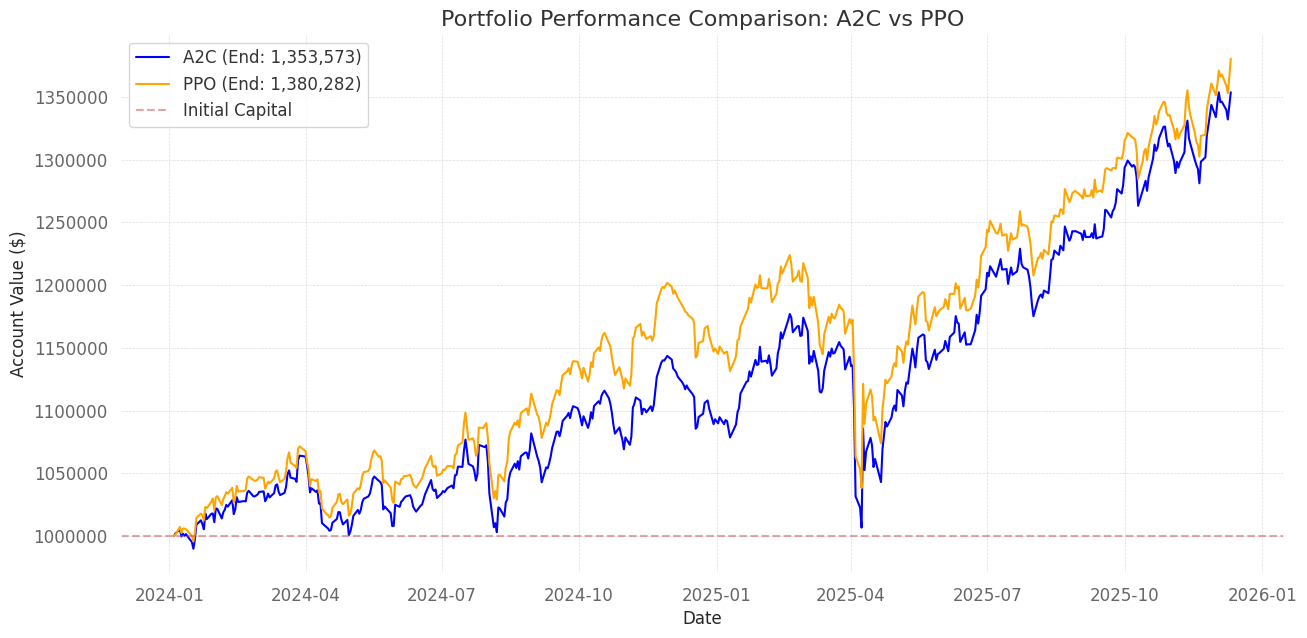

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [35]:
import matplotlib.pyplot as plt
import pandas as pd

# --- 1. CHUẨN BỊ DỮ LIỆU ---
# Đảm bảo cột Date được xử lý đúng cho cả 2 dataframe
data_a2c = df_a2c.copy()
data_ppo = df_ppo.copy()

# Chuyển đổi sang datetime nếu chưa phải
data_a2c['date'] = pd.to_datetime(data_a2c['date'])
data_ppo['date'] = pd.to_datetime(data_ppo['date'])

# Set index là date để vẽ cho chuẩn trục thời gian
data_a2c.set_index('date', inplace=True)
data_ppo.set_index('date', inplace=True)

# Lấy cột giá trị tài khoản
val_a2c = data_a2c['account_value'] if 'account_value' in data_a2c.columns else data_a2c['total_assets']
val_ppo = data_ppo['account_value'] if 'account_value' in data_ppo.columns else data_ppo['total_assets']

# --- 2. VẼ BIỂU ĐỒ SO SÁNH ---
plt.figure(figsize=(15, 7))

# Vẽ đường A2C
plt.plot(val_a2c.index, val_a2c.values, label=f'A2C (End: {val_a2c.iloc[-1]:,.0f})', color='blue', linewidth=1.5)

# Vẽ đường PPO
plt.plot(val_ppo.index, val_ppo.values, label=f'PPO (End: {val_ppo.iloc[-1]:,.0f})', color='orange', linewidth=1.5)

# Thêm đường vốn gốc (1 triệu) để dễ so sánh
plt.axhline(y=1000000, color='r', linestyle='--', alpha=0.5, label='Initial Capital')

# Trang trí biểu đồ
plt.title('Portfolio Performance Comparison: A2C vs PPO', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Account Value ($)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)

# Định dạng trục Y cho dễ đọc (ví dụ: 1,200,000 thay vì 1.2e6)
plt.gcf().axes[0].yaxis.get_major_formatter().set_scientific(False)

plt.show()

[*********************100%***********************]  1 of 1 completed

📅 Giai đoạn so sánh: 2024-01-04 đến 2025-12-11
📉 Đang tải dữ liệu Dow Jones (^DJI)...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)

/tmp/ipython-input-307702499.py:85: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(['{:,.0f}'.format(x) for x in current_values])
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


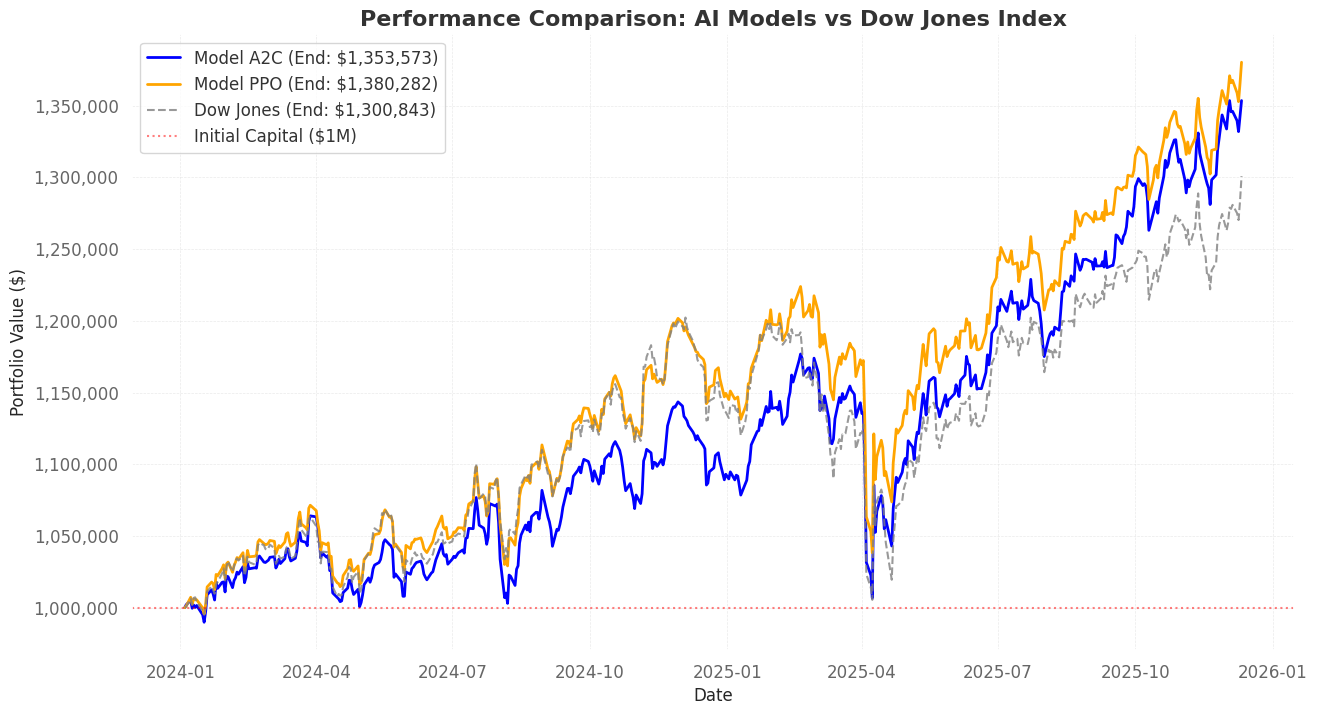


📊 BẢNG TỔNG KẾT HIỆU QUẢ:
Chiến lược      | Lợi nhuận (%)   | Giá trị cuối ($)    
-------------------------------------------------------
A2C             |         35.36% |          1,353,573
PPO             |         38.03% |          1,380,282
Dow Jones       |         30.08% |          1,300,843


In [36]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

# --- 1. CHUẨN BỊ DỮ LIỆU MODEL ---
# Đảm bảo dữ liệu model đã sẵn sàng
if 'df_a2c' not in globals() or 'df_ppo' not in globals():
    raise ValueError("❌ Thiếu biến df_a2c hoặc df_ppo. Hãy chạy Cell 20 trước!")

# Copy để xử lý
data_a2c = df_a2c.copy()
data_ppo = df_ppo.copy()

# Xử lý date và set index
data_a2c['date'] = pd.to_datetime(data_a2c['date'])
data_ppo['date'] = pd.to_datetime(data_ppo['date'])
data_a2c.set_index('date', inplace=True)
data_ppo.set_index('date', inplace=True)

# Lấy ngày bắt đầu và kết thúc từ dữ liệu backtest
start_date = data_a2c.index[0]
end_date = data_a2c.index[-1]
print(f"📅 Giai đoạn so sánh: {start_date.date()} đến {end_date.date()}")

# --- 2. TẢI DỮ LIỆU CHỈ SỐ (BENCHMARK) ---
# Tải Dow Jones (^DJI)
print("📉 Đang tải dữ liệu Dow Jones (^DJI)...")
dji_df = yf.download("^DJI", start=start_date, end=end_date + pd.Timedelta(days=1))

# Xử lý dữ liệu Benchmark
if len(dji_df) > 0:
    # Lấy giá đóng cửa (Close hoặc Adj Close)
    if 'Adj Close' in dji_df.columns:
        benchmark_data = dji_df['Adj Close']
    else:
        benchmark_data = dji_df['Close']

    # Nếu kết quả trả về là DataFrame (do yfinance mới), chuyển về Series
    if isinstance(benchmark_data, pd.DataFrame):
        benchmark_data = benchmark_data.iloc[:, 0]

    # Lọc chỉ lấy các ngày có trong kết quả model (để khớp biểu đồ)
    # Dùng reindex để khớp ngày, ffill để lấp lỗ hổng nếu lệch ngày lễ
    benchmark_data = benchmark_data.reindex(data_a2c.index, method='ffill')

    # --- 3. CHUẨN HÓA VỀ VỐN GỐC (1 TRIỆU $) ---
    initial_capital = 1000000

    # Tính tỷ lệ tăng trưởng tích lũy của Benchmark
    benchmark_returns = benchmark_data.pct_change().fillna(0)
    benchmark_cum_returns = (1 + benchmark_returns).cumprod()

    # Quy đổi ra tiền: Giá trị = Vốn gốc * Tăng trưởng tích lũy
    benchmark_value = initial_capital * benchmark_cum_returns

    # Tính lợi nhuận cuối cùng để hiển thị
    end_val_dji = benchmark_value.iloc[-1]

    # --- 4. VẼ BIỂU ĐỒ SO SÁNH 3 ĐƯỜNG ---
    plt.figure(figsize=(15, 8))

    # Model A2C
    val_a2c = data_a2c['account_value'] if 'account_value' in data_a2c.columns else data_a2c['total_assets']
    plt.plot(val_a2c.index, val_a2c, label=f'Model A2C (End: ${val_a2c.iloc[-1]:,.0f})', color='blue', linewidth=2)

    # Model PPO
    val_ppo = data_ppo['account_value'] if 'account_value' in data_ppo.columns else data_ppo['total_assets']
    plt.plot(val_ppo.index, val_ppo, label=f'Model PPO (End: ${val_ppo.iloc[-1]:,.0f})', color='orange', linewidth=2)

    # Benchmark (Dow Jones)
    plt.plot(benchmark_value.index, benchmark_value, label=f'Dow Jones (End: ${end_val_dji:,.0f})', color='gray', linestyle='--', linewidth=1.5, alpha=0.8)

    # Đường vốn gốc
    plt.axhline(y=initial_capital, color='red', linestyle=':', label='Initial Capital ($1M)', alpha=0.5)

    # Trang trí
    plt.title('Performance Comparison: AI Models vs Dow Jones Index', fontsize=16, fontweight='bold')
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Portfolio Value ($)', fontsize=12)
    plt.legend(fontsize=12, loc='upper left')
    plt.grid(True, which='major', linestyle='--', alpha=0.6)

    # Định dạng trục Y sang dạng tiền tệ (1,200,000)
    current_values = plt.gca().get_yticks()
    plt.gca().set_yticklabels(['{:,.0f}'.format(x) for x in current_values])

    plt.show()

    # --- 5. IN RA BẢNG SO SÁNH CHỈ SỐ ---
    print("\n📊 BẢNG TỔNG KẾT HIỆU QUẢ:")
    print(f"{'Chiến lược':<15} | {'Lợi nhuận (%)':<15} | {'Giá trị cuối ($)':<20}")
    print("-" * 55)

    def calc_perf(name, series):
        total_ret = (series.iloc[-1] - initial_capital) / initial_capital * 100
        print(f"{name:<15} | {total_ret:>13.2f}% | {series.iloc[-1]:>18,.0f}")

    calc_perf("A2C", val_a2c)
    calc_perf("PPO", val_ppo)
    calc_perf("Dow Jones", benchmark_value)

else:
    print("❌ Không tải được dữ liệu Dow Jones. Vui lòng kiểm tra lại kết nối mạng hoặc yfinance.")